# Soft assignment, coresets & diagnostics

Beyond hard labels, a fitted `Betula` exposes the structure it learned: soft posteriors and
confidence, a weighted-point **coreset** you can refit anything on, and structural **diagnostics**
and **profiles** for each cluster.

```bash
pip install betula-cluster matplotlib seaborn pandas scikit-learn
```

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

from betula_cluster import Betula

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold"})


def ari(a, b):
    a, b = np.asarray(a), np.asarray(b)
    cont = pd.crosstab(a, b).to_numpy().astype(float)
    comb = lambda m: (m * (m - 1) / 2).sum()
    s, sa, sb, t = comb(cont), comb(cont.sum(1)), comb(cont.sum(0)), comb(np.array([len(a)]))
    exp = sa * sb / t
    return float((s - exp) / (0.5 * (sa + sb) - exp))


X, y = make_blobs(n_samples=12_000, centers=4, cluster_std=1.3, random_state=0)
X = X.astype(np.float64)
est = Betula(n_clusters=4, feature="diagonal", method="gmm", threshold=0.1, seed=1).fit(X)

## `predict_proba` & `assignment_confidence`

The GMM heads return true posterior responsibilities. The **confidence** is the max per-row
probability — low values flag boundary / ambiguous points (here, where blobs overlap).

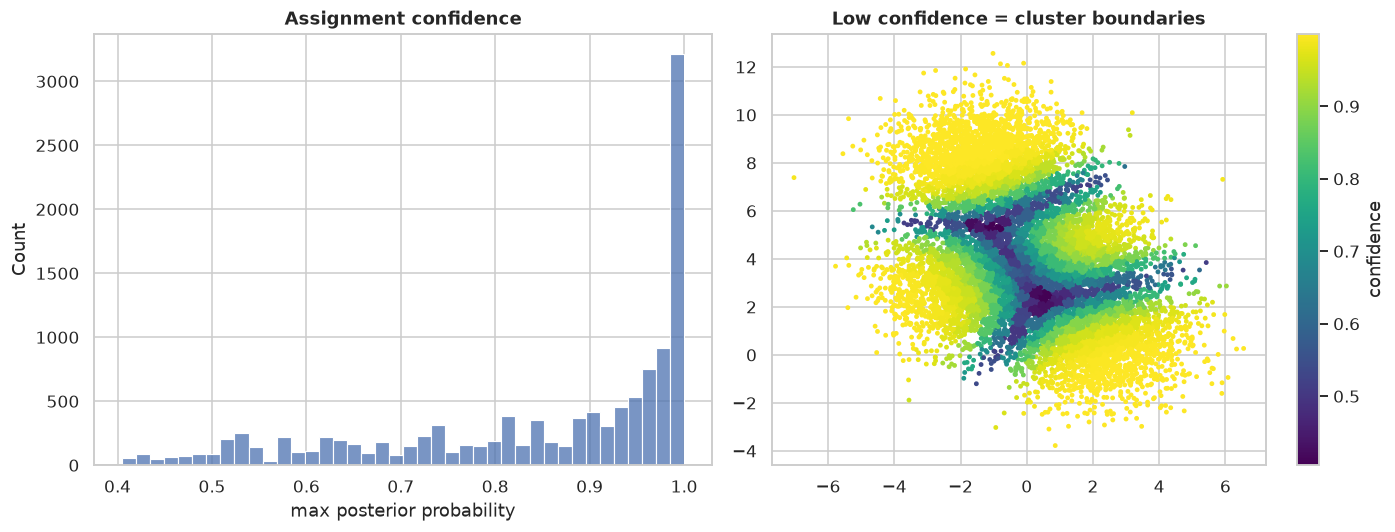

In [2]:
conf = np.asarray(est.assignment_confidence(X))
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(conf, bins=40, ax=axes[0])
axes[0].set(title="Assignment confidence", xlabel="max posterior probability")
sc = axes[1].scatter(X[:, 0], X[:, 1], c=conf, cmap="viridis", s=10, linewidth=0)
axes[1].set_title("Low confidence = cluster boundaries")
plt.colorbar(sc, ax=axes[1], label="confidence")
plt.tight_layout()
plt.show()

## A streaming coreset — refit anything on a tiny weighted summary

`export_coreset()` returns the CF-tree leaves as weighted points. Fitting scikit-learn `KMeans` on
the coreset (a few hundred weighted rows) matches fitting it on all 12,000 points — at a fraction of
the size.

In [3]:
core = est.export_coreset()
km_full = KMeans(n_clusters=4, n_init=10, random_state=0).fit(X)
km_core = KMeans(n_clusters=4, n_init=10, random_state=0).fit(core.centers, sample_weight=core.weights)
pd.DataFrame(
    {
        "fit on": ["full data (12,000 pts)", f"coreset ({len(core.centers)} weighted pts)"],
        "rows used": [len(X), len(core.centers)],
        "ARI of labels vs each other": ["—", round(ari(km_full.predict(X), km_core.predict(X)), 3)],
    }
)

,fit on,rows used,ARI of labels vs each other
0,"full data (12,000 pts)",12000,—
1,coreset (902 weighted pts),902,0.985


## Structural diagnostics

In [4]:
diag = est.diagnostics()
pd.Series(diag).to_frame("value")

,value
n_samples,12000.000000
n_microclusters,902.000000
compression_ratio,13.303769
n_rebuilds,0.000000
threshold,0.100000
microcluster_radius_p50,0.142134
microcluster_radius_p90,0.176142
microcluster_radius_p99,0.198186
n_clusters,4.000000
cluster_mass_min,2810.000000


## Per-cluster profile (JSON-able — e.g. to feed an LLM that names clusters)

In [5]:
prof = est.cluster_profile(0)
print("cluster 0:")
print("  size   :", prof["size"])
print("  radius :", round(prof["radius"], 3))
print("  center :", np.round(prof["center"], 2).tolist())
print("  nearest:", [(p["cluster_id"], round(p["distance"], 2)) for p in prof["nearest_clusters"]])

cluster 0:
  size   : 3040
  radius : 1.707
  center : [2.08, 0.78]
  nearest: [(3, 3.72), (2, 4.35), (1, 7.86)]


## Representatives — exemplars to show a human

Four selection strategies: the medoid (most typical), boundary cases, outliers, and a diverse spread.

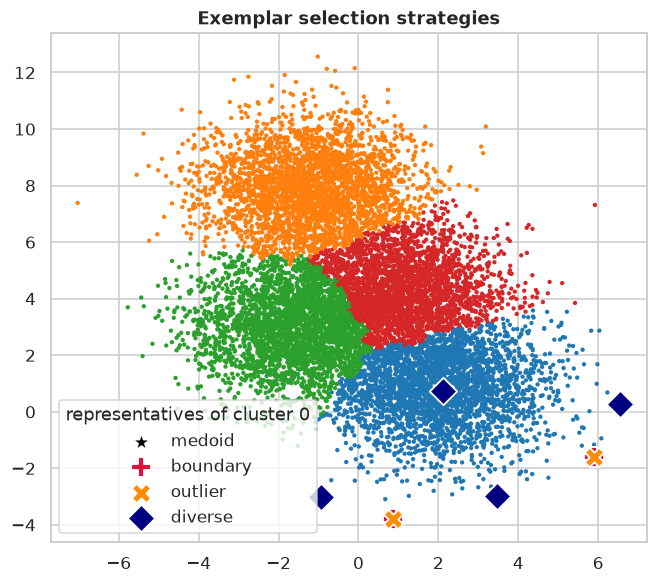

,medoid,boundary,outlier,diverse
0,3299,38,38,3299
1,7595,2658,2658,38
2,7062,7816,7816,7816
3,10887,6850,6850,11315


In [6]:
reps = {m: est.representatives(X, cluster_id=0, method=m, k=4).tolist() for m in ["medoid", "boundary", "outlier", "diverse"]}
fig, ax = plt.subplots(figsize=(7, 6))
sns.scatterplot(x=X[:, 0], y=X[:, 1], hue=np.asarray(est.predict(X)), palette="tab10", s=8, linewidth=0, legend=False, ax=ax)
markers = {"medoid": ("*", "black"), "boundary": ("P", "crimson"), "outlier": ("X", "darkorange"), "diverse": ("D", "navy")}
for m, idx in reps.items():
    mk, col = markers[m]
    ax.scatter(*X[idx].T, marker=mk, c=col, s=160, edgecolor="white", linewidth=1.2, label=m, zorder=5)
ax.legend(title="representatives of cluster 0")
ax.set_title("Exemplar selection strategies")
plt.show()
pd.DataFrame({m: idx for m, idx in reps.items()})